# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [2]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [3]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [6]:
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(".")

print("Done.")

Done.


## 4. Load the Data


In [8]:
def load_har_data(root_dir="UCI HAR Dataset"):
    X_train = pd.read_csv(f"{root_dir}/train/X_train.txt", sep=r'\s+', header=None).values
    y_train = pd.read_csv(f"{root_dir}/train/y_train.txt", sep=r'\s+', header=None).values.flatten()
    X_test  = pd.read_csv(f"{root_dir}/test/X_test.txt",  sep=r'\s+', header=None).values
    y_test  = pd.read_csv(f"{root_dir}/test/y_test.txt",  sep=r'\s+', header=None).values.flatten()

    y_train = y_train - 1
    y_test  = y_test  - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]  # 561
num_classes  = len(class_names)  # 6

## 5. Quick Inspection


In [9]:
# TODO:
# Count samples per class
class_counts = pd.Series(y_train).value_counts().sort_index()

# Create summary table
summary_table = pd.DataFrame({
    "Class Index": class_counts.index,
    "Class Name": [class_names[i] for i in class_counts.index],
    "Training Samples": class_counts.values
})

# Display table
print(summary_table)


   Class Index          Class Name  Training Samples
0            0             WALKING              1226
1            1    WALKING_UPSTAIRS              1073
2            2  WALKING_DOWNSTAIRS               986
3            3             SITTING              1286
4            4            STANDING              1374
5            5              LAYING              1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [11]:
def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)


Epoch 1/40
92/92 [==============================] - 1s 2ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1398 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1150 - accuracy: 0.9572 - val_loss: 0.2550 - val_accuracy: 0.9164
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0916 - accuracy: 0.9636 - val_loss: 0.1449 - val_accuracy: 0.9422
Epoch 5/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0873 - accuracy: 0.9657 - val_loss: 0.2036 - val_accuracy: 0.9259
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0743 - accuracy: 0.9696 - val_loss: 0.1790 - val_accuracy: 0.9388
Epoch 7/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0662 - accuracy: 0.9747 - val_loss: 0.1292 - val_accuracy: 0.9483
Epoch 8/40
92/92 [==

### Training Curves


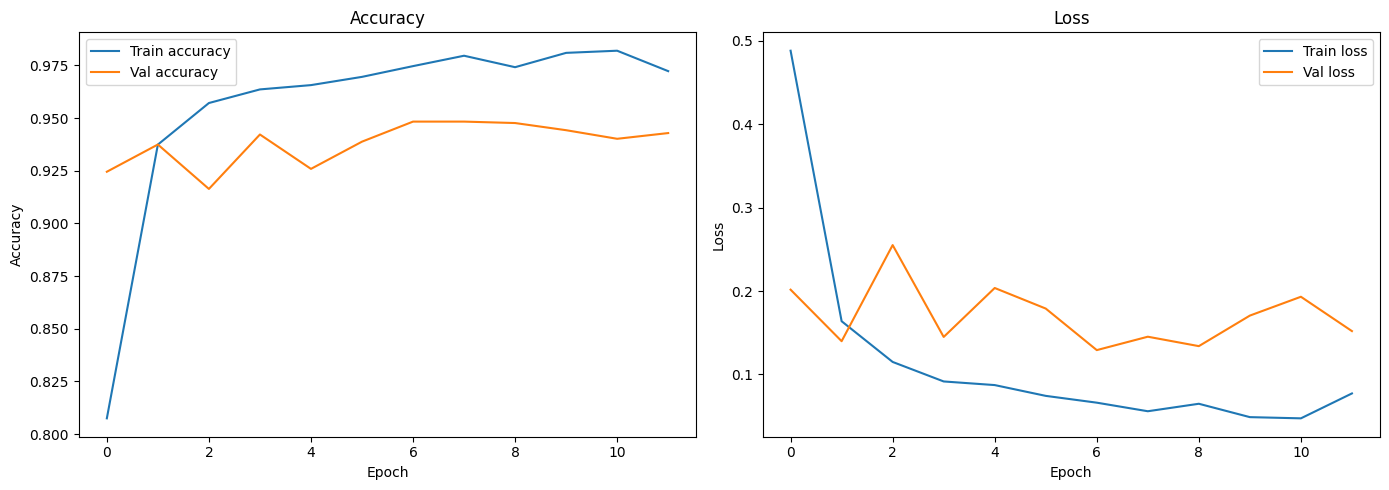

In [13]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train loss')
axes[1].plot(history.history['val_loss'], label='Val loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 462us/step
Test accuracy: 0.9332

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.96      0.98      0.97       496
  WALKING_UPSTAIRS       0.86      0.97      0.92       471
WALKING_DOWNSTAIRS       0.99      0.83      0.90       420
           SITTING       0.94      0.88      0.91       491
          STANDING       0.88      0.95      0.91       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



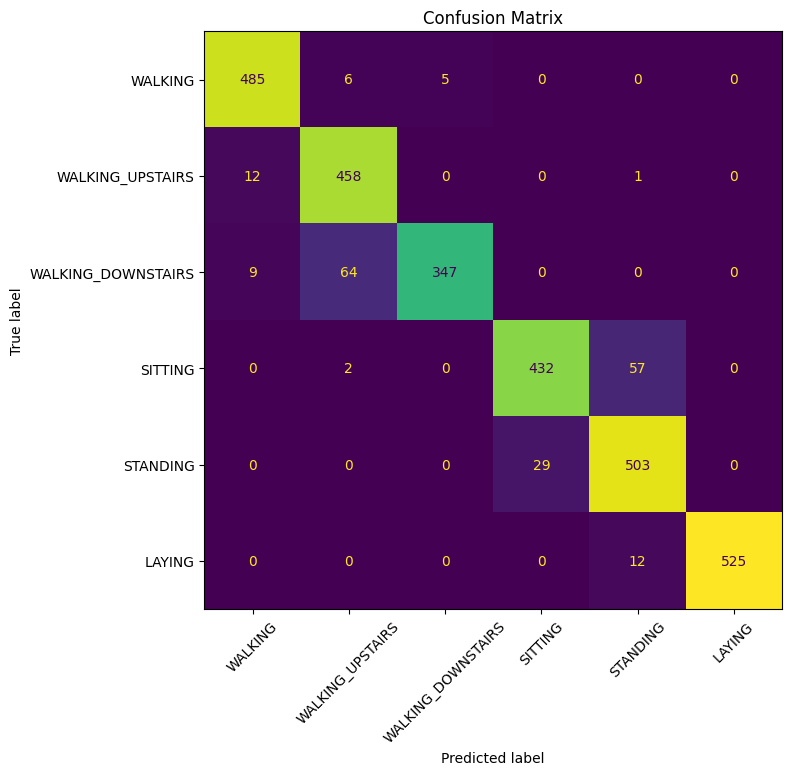

In [14]:
y_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [15]:
def representative_dataset_gen():
    indices = np.random.choice(len(X_train), 300, replace=False)
    for i in indices:
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details  = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale,  input_zero_point  = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]
    y_pred = []
    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] in (np.int8, np.uint8):
            x = (x / input_scale + input_zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])
    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()

## 9. Post-Training Quantization (PTQ)


In [17]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

tflite_models = {
    "FP32":          convert_to_tflite_fp32(baseline_model),
    "Dynamic Range": convert_to_tflite_dynamic_range(baseline_model),
    "Float16":       convert_to_tflite_float16(baseline_model),
    "Int8":          convert_to_tflite_int8(baseline_model),
}

filenames = {
    "FP32":          "model_fp32.tflite",
    "Dynamic Range": "model_dynamic_range.tflite",
    "Float16":       "model_float16.tflite",
    "Int8":          "model_int8.tflite",
}

results = {}
for name, model in tflite_models.items():
    fname = filenames[name]
    size_kb = save_binary_model(model, fname)
    acc, _  = evaluate_tflite_model(model, X_test, y_test)
    results[name] = {"file": fname, "size_kb": size_kb, "accuracy": acc}
    print(f"{name:>15}  |  {size_kb:8.2f} KB  |  acc: {acc:.4f}")

INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpjimc9o8s/assets


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpjimc9o8s/assets
2026-05-28 01:43:35.447268: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-28 01:43:35.447423: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-28 01:43:35.448052: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpjimc9o8s
2026-05-28 01:43:35.448568: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-28 01:43:35.448573: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpjimc9o8s
2026-05-28 01:43:35.451574: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-28 01:43:35.503995: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpry_2c_zs/assets


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpry_2c_zs/assets
2026-05-28 01:43:35.807714: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-28 01:43:35.807724: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-28 01:43:35.807816: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpry_2c_zs
2026-05-28 01:43:35.808303: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-28 01:43:35.808306: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpry_2c_zs
2026-05-28 01:43:35.809744: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-28 01:43:35.828789: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp1ngxda58/assets


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp1ngxda58/assets
2026-05-28 01:43:36.082459: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-28 01:43:36.082467: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-28 01:43:36.082558: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp1ngxda58
2026-05-28 01:43:36.083056: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-28 01:43:36.083060: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp1ngxda58
2026-05-28 01:43:36.084308: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-28 01:43:36.103440: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp4dxxp9r4/assets


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp4dxxp9r4/assets
/Users/adityabhagwani/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-28 01:43:36.571754: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-28 01:43:36.571764: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-28 01:43:36.571860: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmp4dxxp9r4
2026-05-28 01:43:36.572350: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-28 01:43:36.572355: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/ywgpwq

           FP32  |    726.72 KB  |  acc: 0.9332
  Dynamic Range  |    186.11 KB  |  acc: 0.9335
        Float16  |    365.71 KB  |  acc: 0.9332
           Int8  |    185.34 KB  |  acc: 0.9338


## 10. PTQ Comparison: Accuracy and Model Size


In [18]:
comparison_df = pd.DataFrame([
    {
        "Model Family": "Baseline DNN",
        "Format":       name,
        "Test Accuracy": results[name]["accuracy"],
        "Model Size (KB)": results[name]["size_kb"],
    }
    for name in results
])

print(comparison_df.to_string(index=False))

Model Family        Format  Test Accuracy  Model Size (KB)
Baseline DNN          FP32       0.933152       726.718750
Baseline DNN Dynamic Range       0.933492       186.109375
Baseline DNN       Float16       0.933152       365.710938
Baseline DNN          Int8       0.933831       185.335938


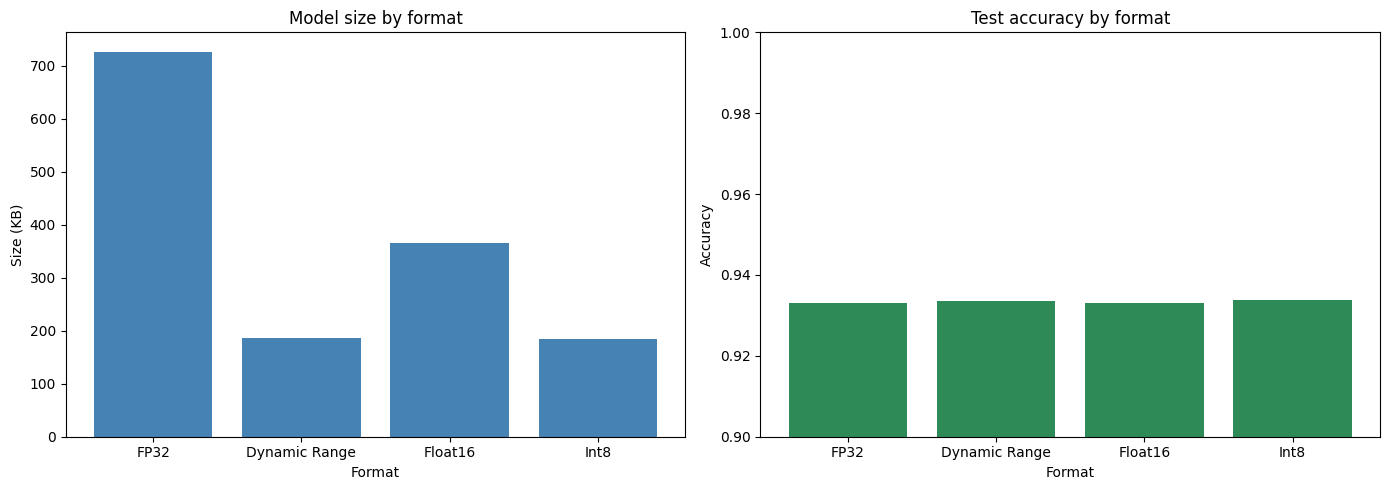

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(comparison_df["Format"], comparison_df["Model Size (KB)"], color='steelblue')
axes[0].set_title("Model size by format")
axes[0].set_xlabel("Format")
axes[0].set_ylabel("Size (KB)")

axes[1].bar(comparison_df["Format"], comparison_df["Test Accuracy"], color='seagreen')
axes[1].set_title("Test accuracy by format")
axes[1].set_xlabel("Format")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.9, 1.0)

plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


Classification Report (Int8):
                    precision    recall  f1-score   support

           WALKING       0.96      0.98      0.97       496
  WALKING_UPSTAIRS       0.86      0.97      0.92       471
WALKING_DOWNSTAIRS       0.98      0.83      0.90       420
           SITTING       0.94      0.88      0.91       491
          STANDING       0.88      0.95      0.91       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



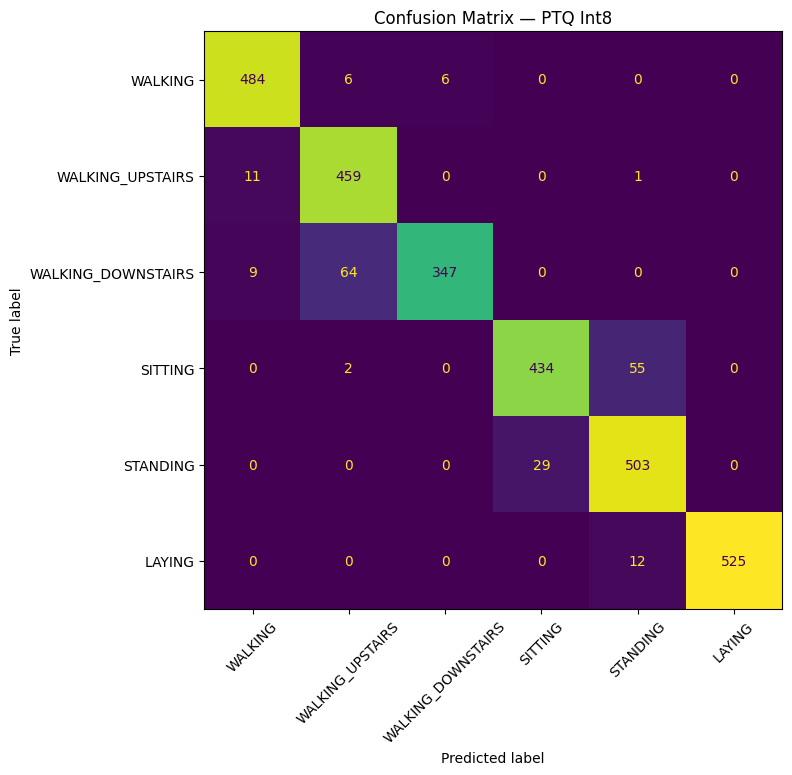

In [20]:
_, y_pred_int8 = evaluate_tflite_model(tflite_models["Int8"], X_test, y_test)

print("Classification Report (Int8):")
print(classification_report(y_test, y_pred_int8, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_int8)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix — PTQ Int8")
plt.tight_layout()
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [21]:
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

qat_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 6)                 3

### Fine-Tune the QAT Model


In [22]:
qat_history = qat_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8
92/92 [==============================] - 1s 3ms/step - loss: 0.0471 - accuracy: 0.9855 - val_loss: 0.1259 - val_accuracy: 0.9449
Epoch 2/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0388 - accuracy: 0.9864 - val_loss: 0.1227 - val_accuracy: 0.9490
Epoch 3/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0374 - accuracy: 0.9866 - val_loss: 0.1341 - val_accuracy: 0.9504
Epoch 4/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0344 - accuracy: 0.9876 - val_loss: 0.1262 - val_accuracy: 0.9477
Epoch 5/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0333 - accuracy: 0.9879 - val_loss: 0.1626 - val_accuracy: 0.9443
Epoch 6/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0332 - accuracy: 0.9881 - val_loss: 0.1433 - val_accuracy: 0.9497
Epoch 7/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0331 - accuracy: 0.9888 - val_loss: 0.1307 - val_accuracy: 0.9497
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [23]:
y_prob_qat = qat_model.predict(X_test)
y_pred_qat = np.argmax(y_prob_qat, axis=1)

test_accuracy_qat = accuracy_score(y_test, y_pred_qat)
print(f"QAT Test Accuracy: {test_accuracy_qat:.4f}")

print("\nClassification Report (QAT):")
print(classification_report(y_test, y_pred_qat, target_names=class_names))


93/93 [==============================] - 0s 633us/step
QAT Test Accuracy: 0.9315

Classification Report (QAT):
                    precision    recall  f1-score   support

           WALKING       0.92      0.97      0.95       496
  WALKING_UPSTAIRS       0.95      0.90      0.92       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.96      0.85      0.90       491
          STANDING       0.84      0.97      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [24]:
qat_int8_model = convert_to_tflite_int8(qat_model)

qat_int8_size_kb = save_binary_model(qat_int8_model, "model_qat_int8.tflite")
qat_int8_acc, y_pred_qat_int8 = evaluate_tflite_model(qat_int8_model, X_test, y_test)

print(f"QAT Int8 — Size: {qat_int8_size_kb:.2f} KB  |  Accuracy: {qat_int8_acc:.4f}")


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpypgraksi/assets


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpypgraksi/assets


QAT Int8 — Size: 185.70 KB  |  Accuracy: 0.9325


/Users/adityabhagwani/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-28 01:45:38.449525: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-28 01:45:38.449884: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-28 01:45:38.450190: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpypgraksi
2026-05-28 01:45:38.451319: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-28 01:45:38.451323: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpypgraksi
2026-05-28 01:45:38.455257: I tensorflow/cc/saved_model/loader.c

## 12. PTQ Int8 vs QAT Int8


In [25]:
quant_comparison_df = pd.DataFrame([
    {
        "Model":            "PTQ Int8",
        "Test Accuracy":    results["Int8"]["accuracy"],
        "Model Size (KB)":  results["Int8"]["size_kb"],
    },
    {
        "Model":            "QAT Int8",
        "Test Accuracy":    qat_int8_acc,
        "Model Size (KB)":  qat_int8_size_kb,
    }
])

print(quant_comparison_df.to_string(index=False))

   Model  Test Accuracy  Model Size (KB)
PTQ Int8       0.933831       185.335938
QAT Int8       0.932474       185.695312


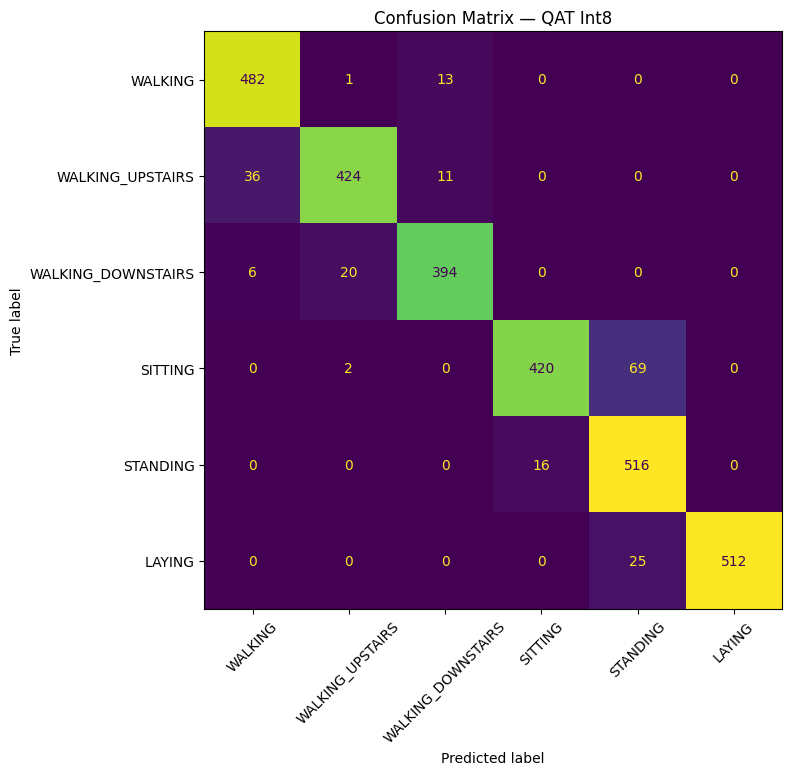

In [26]:
cm_qat = confusion_matrix(y_test, y_pred_qat_int8)
disp_qat = ConfusionMatrixDisplay(confusion_matrix=cm_qat, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp_qat.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix — QAT Int8")
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
